## 1. Install Dependencies



In [6]:
import sys
!{sys.executable} -m pip install --user librosa==0.10.1 soundfile numpy pandas matplotlib seaborn --quiet



[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Import Libraries


In [7]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf

# Reproducibility seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Libraries loaded successfully.')
print(f'librosa version : {librosa.__version__}')
print(f'numpy version   : {np.__version__}')
print(f'pandas version  : {pd.__version__}')


Libraries loaded successfully.
librosa version : 0.10.1
numpy version   : 2.4.6
pandas version  : 3.0.3


## 3. Define Paths




In [ ]:
DATASET_PATH = r"C:\Users\34610\Desktop\UNIVERSIDAD\Máster\Integracion tecnologias\Proyecto con augmentation\scenes_stereo"  

OUTPUT_DIR = "output_block2"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Dataset path : {DATASET_PATH}')
print(f'Output dir   : {os.path.abspath(OUTPUT_DIR)}')


Dataset path : C:\Users\34610\Desktop\UNIVERSIDAD\Máster\Integracion tecnologias\Proyecto con augmentation\scenes_stereo
Output dir   : c:\Users\34610\Desktop\UNIVERSIDAD\Máster\Integracion tecnologias\Proyecto con augmentation\output_block2


## 4. Define Class Map



In [13]:
CLASSES = [
    'bus', 'busystreet', 'office', 'openairmarket', 'park',
    'quietstreet', 'restaurant', 'supermarket', 'tube', 'tubestation'
]

CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(CLASSES)}
IDX_TO_CLASS = {idx: cls for cls, idx in CLASS_TO_IDX.items()}

print(f'Number of classes: {len(CLASSES)}')
print(f'Classes: {CLASSES}')


Number of classes: 10
Classes: ['bus', 'busystreet', 'office', 'openairmarket', 'park', 'quietstreet', 'restaurant', 'supermarket', 'tube', 'tubestation']


## 5. Build the File List (Annotations DataFrame)




In [14]:
def extract_label_from_filename(filename):
    """
    Extracts the class label from a DCASE 2013 filename.
    Example: 'busystreet04.wav' -> 'busystreet'
    """
    name = os.path.splitext(filename)[0]   # remove .wav
    label = re.sub(r'\d+$', '', name)       # strip trailing digits
    return label


records = []

for filename in sorted(os.listdir(DATASET_PATH)):
    if not filename.endswith('.wav'):
        continue
    label = extract_label_from_filename(filename)
    if label not in CLASS_TO_IDX:
        print(f'WARNING: Unknown label "{label}" for file "{filename}" — skipping.')
        continue
    records.append({
        'filename' : filename,
        'filepath' : os.path.join(DATASET_PATH, filename),
        'label'    : label,
        'label_idx': CLASS_TO_IDX[label]
    })

df = pd.DataFrame(records)

print(f'Total files found: {len(df)}')
print('Files per class:')
print(df['label'].value_counts().sort_index())
print()
print(df.head(10))


Total files found: 100
Files per class:
label
bus              10
busystreet       10
office           10
openairmarket    10
park             10
quietstreet      10
restaurant       10
supermarket      10
tube             10
tubestation      10
Name: count, dtype: int64

    filename                                           filepath label  \
0  bus01.wav  C:\Users\34610\Desktop\UNIVERSIDAD\Máster\Inte...   bus   
1  bus02.wav  C:\Users\34610\Desktop\UNIVERSIDAD\Máster\Inte...   bus   
2  bus03.wav  C:\Users\34610\Desktop\UNIVERSIDAD\Máster\Inte...   bus   
3  bus04.wav  C:\Users\34610\Desktop\UNIVERSIDAD\Máster\Inte...   bus   
4  bus05.wav  C:\Users\34610\Desktop\UNIVERSIDAD\Máster\Inte...   bus   
5  bus06.wav  C:\Users\34610\Desktop\UNIVERSIDAD\Máster\Inte...   bus   
6  bus07.wav  C:\Users\34610\Desktop\UNIVERSIDAD\Máster\Inte...   bus   
7  bus08.wav  C:\Users\34610\Desktop\UNIVERSIDAD\Máster\Inte...   bus   
8  bus09.wav  C:\Users\34610\Desktop\UNIVERSIDAD\Máster\Inte...   bus 

## 6. Dataset Statistics and Class Distribution


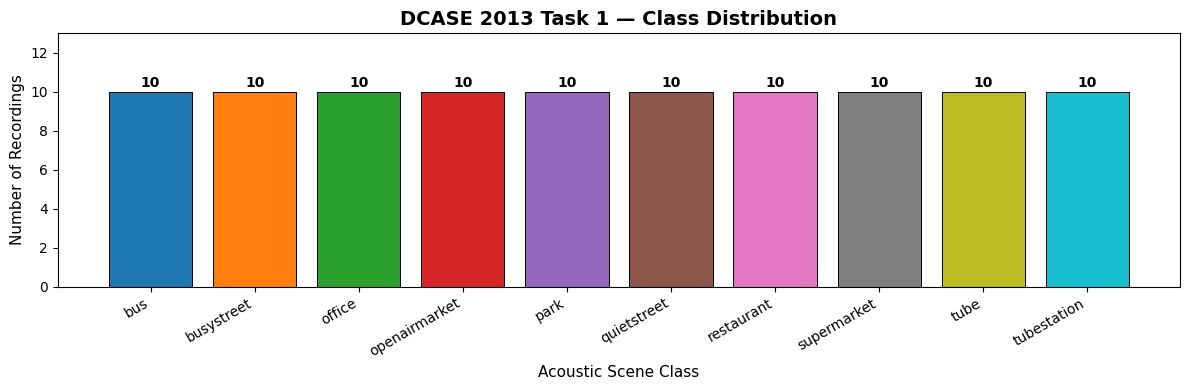

Saved: output_block2\class_distribution.png
Dataset is balanced: True


In [15]:
fig, ax = plt.subplots(figsize=(12, 4))

class_counts = df['label'].value_counts().sort_index()
bars = ax.bar(class_counts.index, class_counts.values,
              color=plt.cm.tab10(np.linspace(0, 1, len(CLASSES))),
              edgecolor='black', linewidth=0.7)

for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('DCASE 2013 Task 1 — Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Acoustic Scene Class', fontsize=11)
ax.set_ylabel('Number of Recordings', fontsize=11)
ax.set_ylim(0, class_counts.max() + 3)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

out_path = os.path.join(OUTPUT_DIR, 'class_distribution.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved: {out_path}')
print(f'Dataset is balanced: {class_counts.nunique() == 1}')


## 7. Audio Inspection: Technical Specifications



In [16]:
print(f'{"Class":<15} {"Sample Rate":>12} {"Channels":>10} {"Duration (s)":>14}')
print('-' * 55)

specs = []
for cls in CLASSES:
    row  = df[df['label'] == cls].iloc[0]
    info = sf.info(row['filepath'])
    specs.append({
        'class'      : cls,
        'sample_rate': info.samplerate,
        'channels'   : info.channels,
        'duration_s' : round(info.duration, 2)
    })
    print(f'{cls:<15} {info.samplerate:>12} {info.channels:>10} {info.duration:>14.2f}')

df_specs = pd.DataFrame(specs)
print()
print('Summary:')
print(f'  Sample rates found  : {df_specs["sample_rate"].unique()}')
print(f'  Channels found      : {df_specs["channels"].unique()}')
print(f'  Durations found (s) : {df_specs["duration_s"].unique()}')


Class            Sample Rate   Channels   Duration (s)
-------------------------------------------------------
bus                    44100          2          30.00
busystreet             44100          2          30.00
office                 44100          2          30.00
openairmarket          44100          2          30.00
park                   44100          2          30.00
quietstreet            44100          2          30.00
restaurant             44100          2          30.00
supermarket            44100          2          30.00
tube                   44100          2          30.00
tubestation            44100          2          30.00

Summary:
  Sample rates found  : [44100]
  Channels found      : [2]
  Durations found (s) : [30.]


## 8. Waveform Visualization




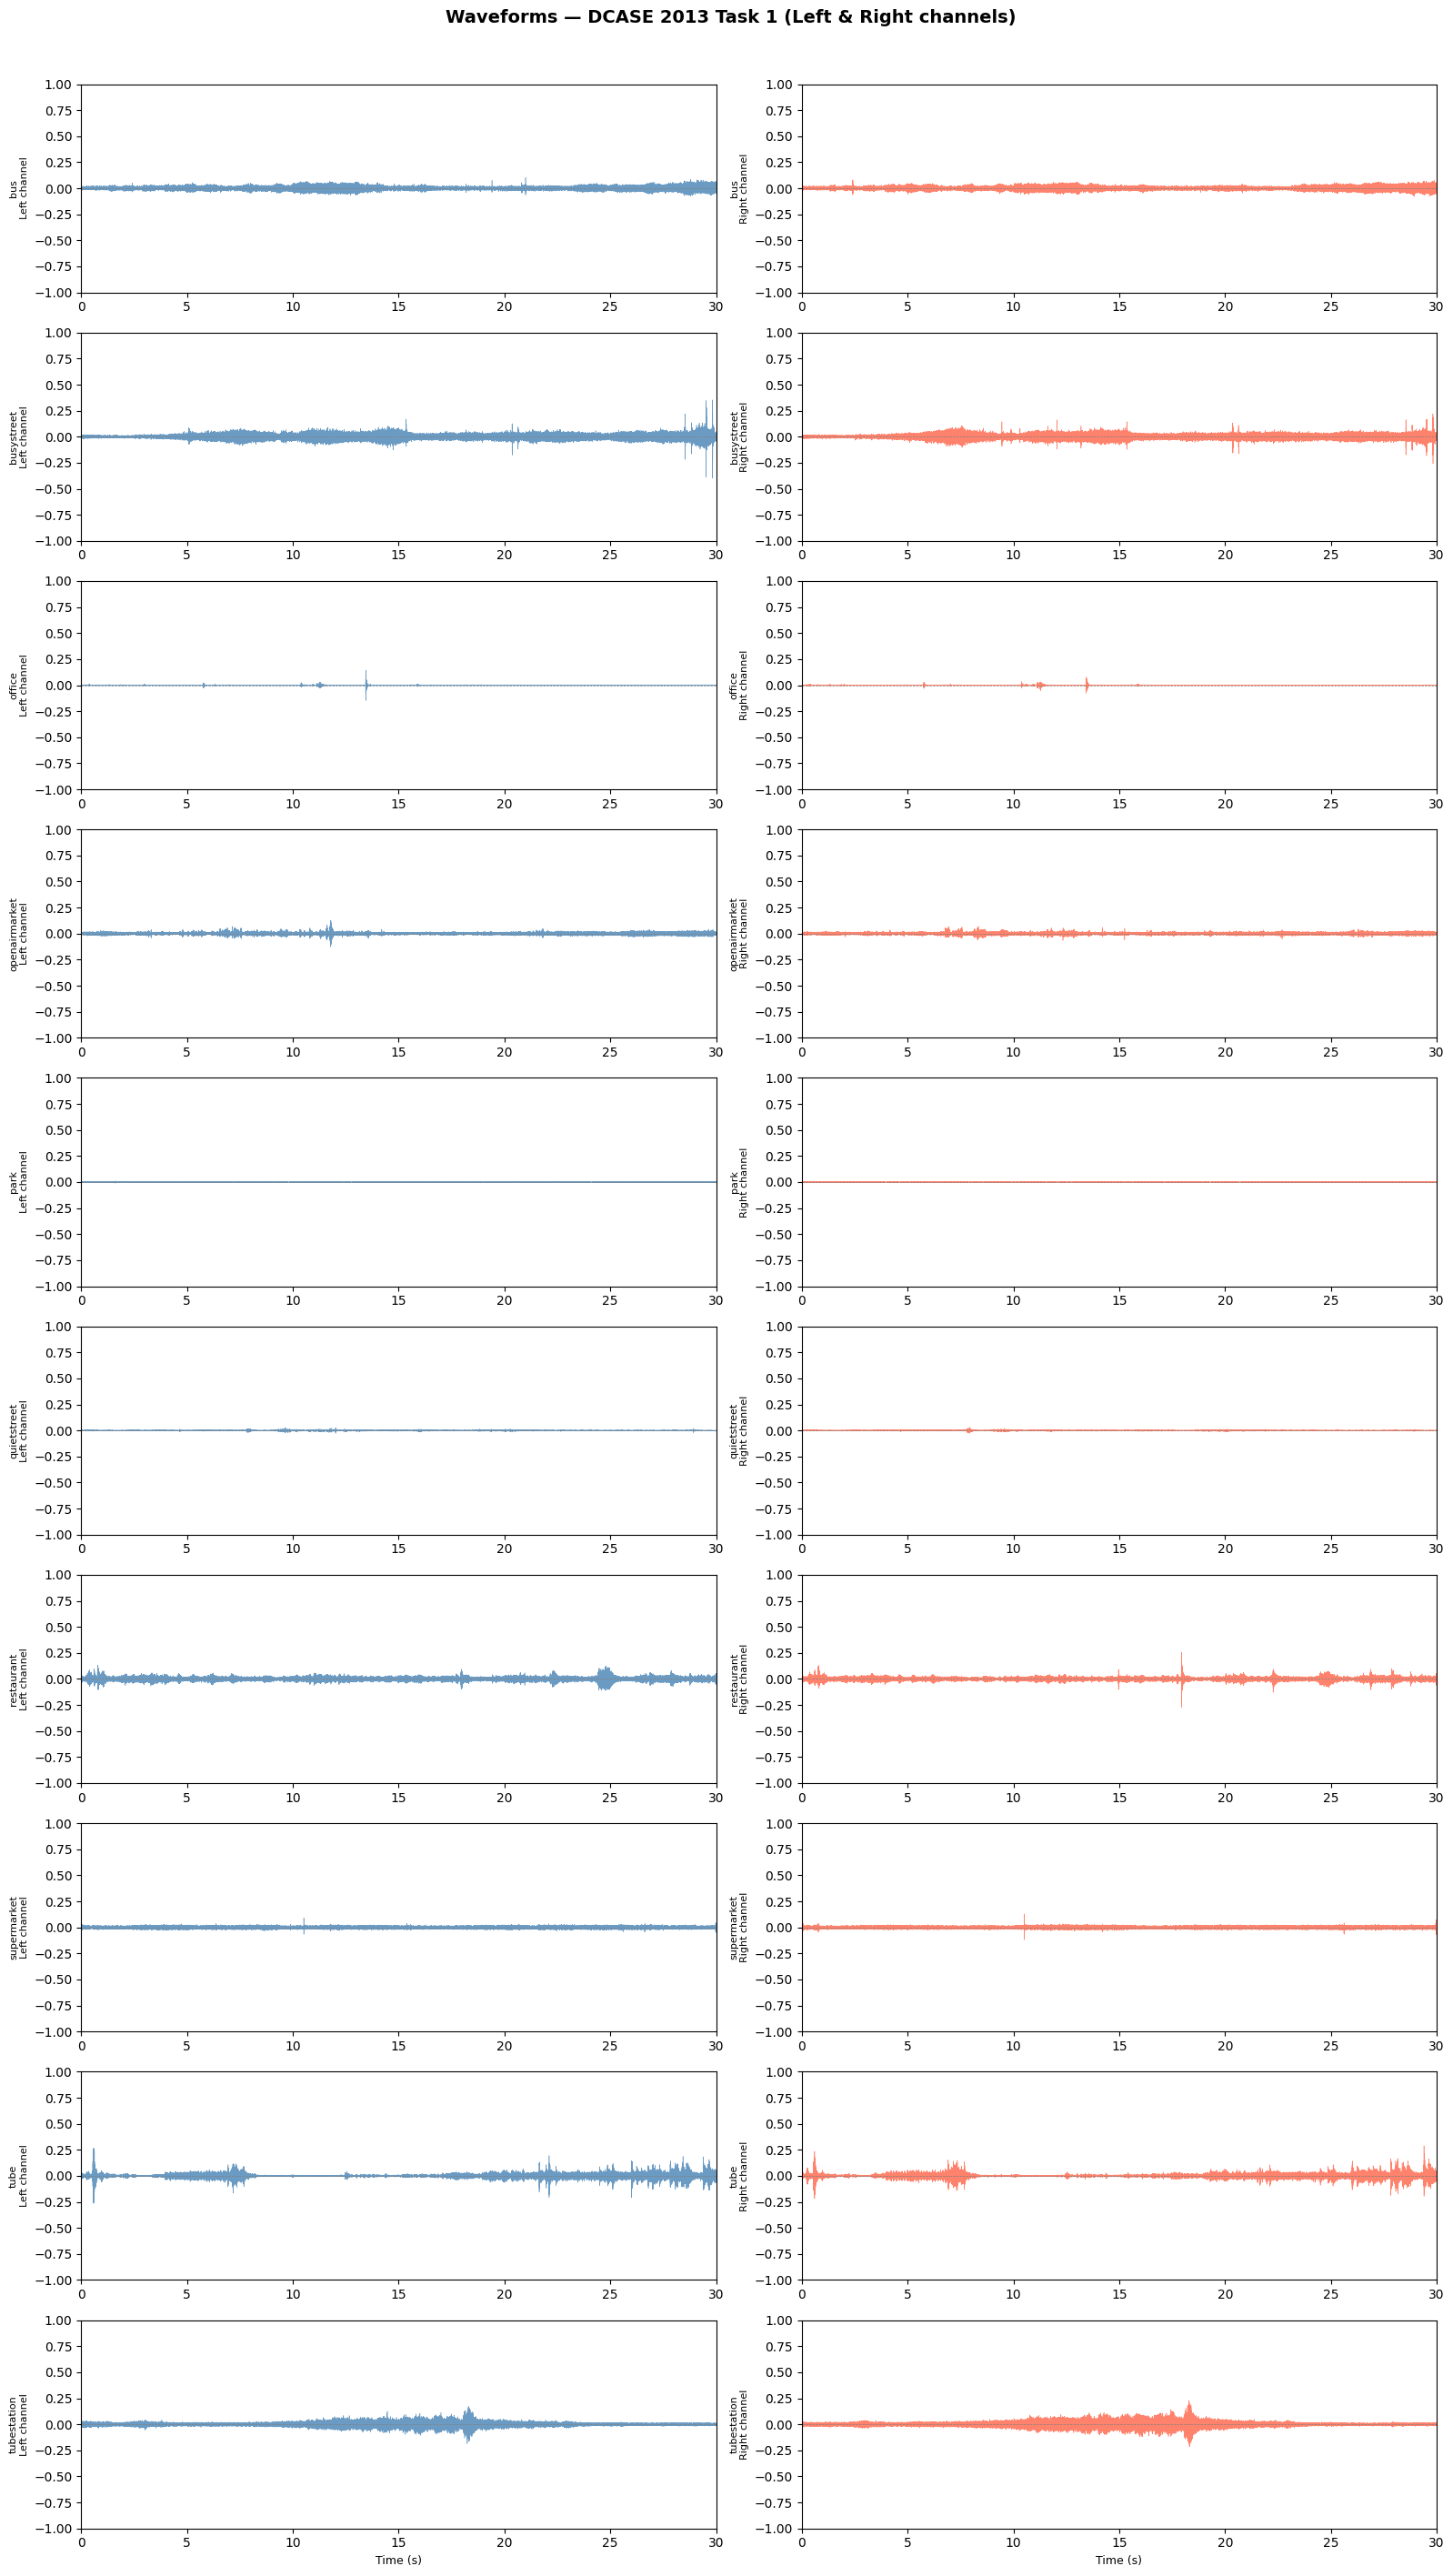

Saved: output_block2\waveforms_all_classes.png


In [17]:
fig, axes = plt.subplots(10, 2, figsize=(16, 28))
fig.suptitle('Waveforms — DCASE 2013 Task 1 (Left & Right channels)',
             fontsize=14, fontweight='bold', y=1.01)

for i, cls in enumerate(CLASSES):
    filepath  = df[df['label'] == cls].iloc[0]['filepath']
    wav, sr   = librosa.load(filepath, sr=None, mono=False)
    time_axis = np.linspace(0, wav.shape[1] / sr, wav.shape[1])

    for ch, (ax, color, ch_name) in enumerate(zip(
            [axes[i, 0], axes[i, 1]],
            ['steelblue', 'tomato'],
            ['Left channel', 'Right channel'])):

        ax.plot(time_axis, wav[ch], color=color, linewidth=0.4, alpha=0.8)
        ax.set_ylabel(f'{cls}\n{ch_name}', fontsize=8)
        ax.set_xlim([0, 30])
        ax.set_ylim([-1, 1])
        ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
        if i == len(CLASSES) - 1:
            ax.set_xlabel('Time (s)', fontsize=9)

plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, 'waveforms_all_classes.png')
plt.savefig(out_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')


## 9. Log-Mel Spectrogram Visualization



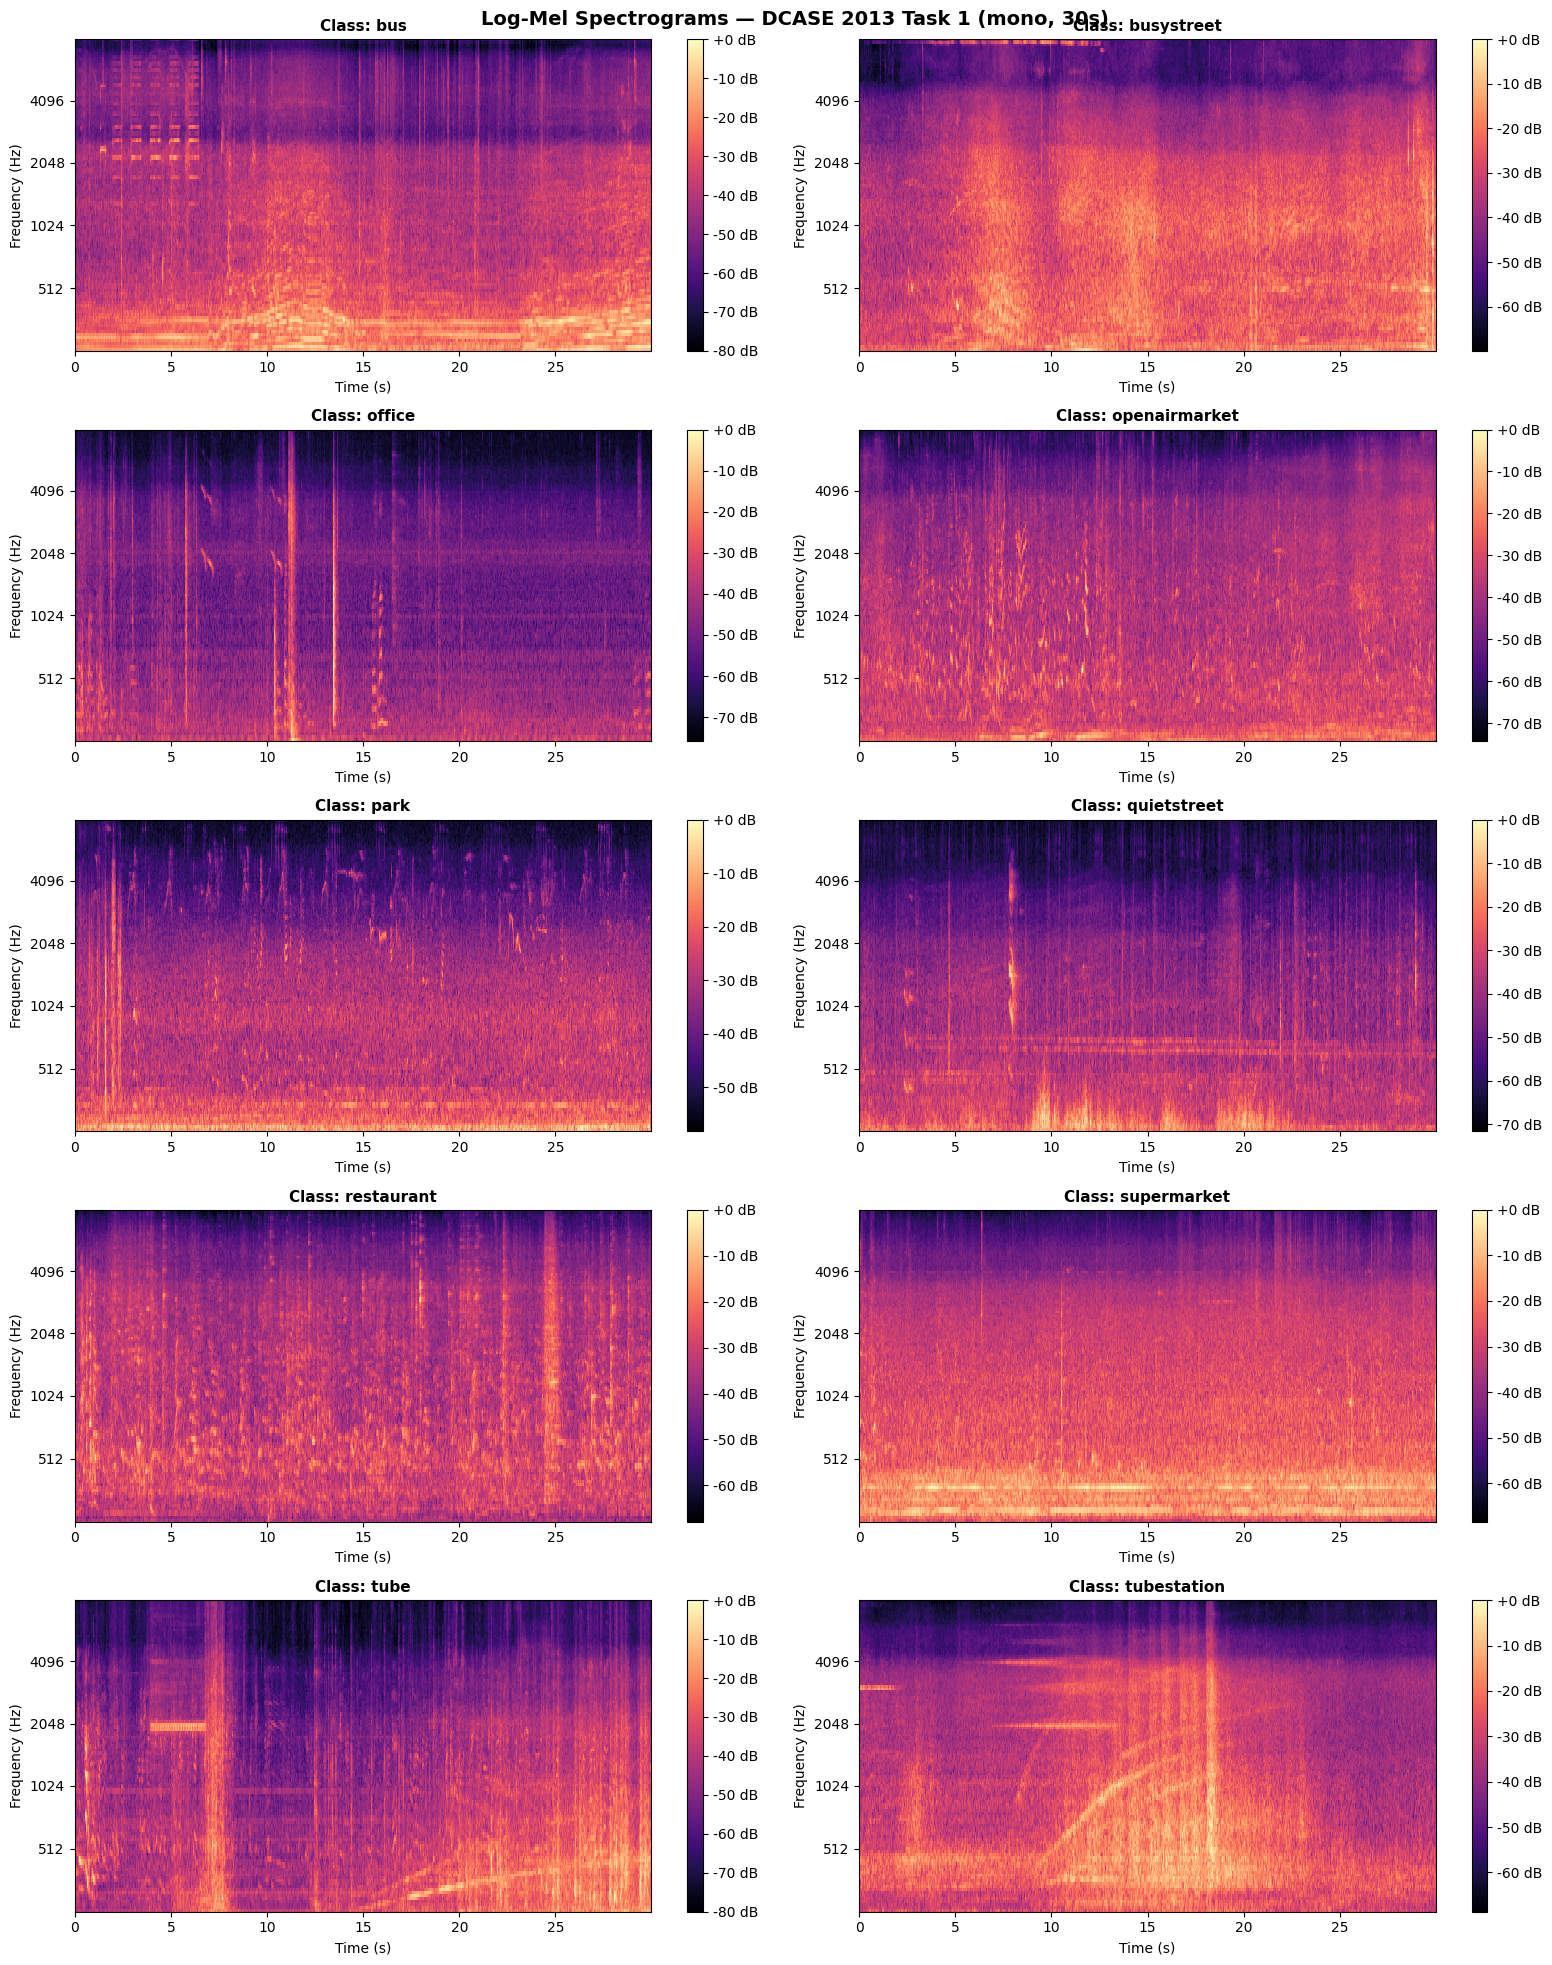

Saved: output_block2\logmel_spectrograms_all_classes.png


In [18]:
SR      = 22050
N_MELS  = 128
N_FFT   = 2048
HOP_LEN = 512
FMIN    = 20
FMAX    = 8000

fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()
fig.suptitle('Log-Mel Spectrograms — DCASE 2013 Task 1 (mono, 30s)',
             fontsize=14, fontweight='bold')

for i, cls in enumerate(CLASSES):
    filepath     = df[df['label'] == cls].iloc[0]['filepath']
    wav, sr      = librosa.load(filepath, sr=SR, mono=True)
    mel_spec     = librosa.feature.melspectrogram(
        y=wav, sr=SR, n_mels=N_MELS, n_fft=N_FFT,
        hop_length=HOP_LEN, fmin=FMIN, fmax=FMAX
    )
    log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)

    img = librosa.display.specshow(
        log_mel_spec, sr=SR, hop_length=HOP_LEN,
        x_axis='time', y_axis='mel', fmin=FMIN, fmax=FMAX,
        ax=axes[i], cmap='magma'
    )
    axes[i].set_title(f'Class: {cls}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Time (s)')
    axes[i].set_ylabel('Frequency (Hz)')
    fig.colorbar(img, ax=axes[i], format='%+2.0f dB')

plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, 'logmel_spectrograms_all_classes.png')
plt.savefig(out_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')


## 10. Audio Playback 




In [ ]:
import subprocess
import sys

target_class = 'park'   

filepath = df[df['label'] == target_class].iloc[0]['filepath']
wav, sr  = librosa.load(filepath, sr=None, mono=False)
print(f'Audio: {os.path.basename(filepath)}')
print(f'Sample rate: {sr} Hz | Channels: {wav.shape[0]} | Duration: {wav.shape[1]/sr:.1f}s')

os.startfile(filepath)        



Audio: park01.wav
Sample rate: 44100 Hz | Channels: 2 | Duration: 30.0s


## 11. Dataset Summary 


In [19]:
print('=' * 60)
print('DCASE 2013 TASK 1 — DATASET SUMMARY')
print('=' * 60)
print(f'Total recordings         : {len(df)}')
print(f'Number of classes        : {len(CLASSES)}')
print(f'Recordings per class     : {len(df) // len(CLASSES)}')
print(f'Audio format             : WAV')
print(f'Number of channels       : 2 (binaural stereo)')
print(f'Original sample rate     : 44100 Hz')
print(f'Target sample rate (ML)  : {SR} Hz')
print(f'Duration per recording   : ~30 seconds')
print(f'Recording conditions     : Field recordings (real environments)')
print(f'Dataset balance          : Balanced (equal files per class)')
print(f'License                  : Academic/research use only (DCASE 2013)')
print()
print('Classes:')
for idx, cls in enumerate(CLASSES):
    print(f'  [{idx}] {cls}')
print('=' * 60)

csv_path = os.path.join(OUTPUT_DIR, 'dcase2013_annotations.csv')
df.to_csv(csv_path, index=False)
print(f'\nAnnotation file saved: {csv_path}')


DCASE 2013 TASK 1 — DATASET SUMMARY
Total recordings         : 100
Number of classes        : 10
Recordings per class     : 10
Audio format             : WAV
Number of channels       : 2 (binaural stereo)
Original sample rate     : 44100 Hz
Target sample rate (ML)  : 22050 Hz
Duration per recording   : ~30 seconds
Recording conditions     : Field recordings (real environments)
Dataset balance          : Balanced (equal files per class)
License                  : Academic/research use only (DCASE 2013)

Classes:
  [0] bus
  [1] busystreet
  [2] office
  [3] openairmarket
  [4] park
  [5] quietstreet
  [6] restaurant
  [7] supermarket
  [8] tube
  [9] tubestation

Annotation file saved: output_block2\dcase2013_annotations.csv


In [13]:
print(df.groupby('label')['filename'].apply(list))

label
bus              [bus01.wav, bus02.wav, bus03.wav, bus04.wav, b...
busystreet       [busystreet01.wav, busystreet02.wav, busystree...
office           [office01.wav, office02.wav, office03.wav, off...
openairmarket    [openairmarket01.wav, openairmarket02.wav, ope...
park             [park01.wav, park02.wav, park03.wav, park04.wa...
quietstreet      [quietstreet01.wav, quietstreet02.wav, quietst...
restaurant       [restaurant01.wav, restaurant02.wav, restauran...
supermarket      [supermarket01.wav, supermarket02.wav, superma...
tube             [tube01.wav, tube02.wav, tube03.wav, tube04.wa...
tubestation      [tubestation01.wav, tubestation02.wav, tubesta...
Name: filename, dtype: object


In [14]:
print(df.groupby('label')['filename'].count())

label
bus              10
busystreet       10
office           10
openairmarket    10
park             10
quietstreet      10
restaurant       10
supermarket      10
tube             10
tubestation      10
Name: filename, dtype: int64
